### **Predicting Bridge Demand: A Linear Regression Workflow**

In [25]:
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

df = pd.read_excel("exemplary_regression_data.xlsx") # Load data from Excel file
df

,Country,Total Bridges #,Population (2024),Land Area (SQKM),Urban Population (2024),Vehicles per country,Number of Households,"C02 Emissions (tons, 2022)",Number of Airports,Renewable Energies (KWH),Waterways,Road & Rail Volumes (18-23 real),Rail Network (km),Road Network (km),Total Network (km),Cement Consumption (Mt)
0,United States,6.215810e+05,345426571,9147420,283249788,305000000,132736055.0,4.853780e+09,15873.0,6.000960e+16,41009.0,643743.81,293564.2,6586610,6880174.2,436.476
1,China,1.111154e+06,1419321278,9388211,936752043,329120000,522689264.0,1.266743e+10,531.0,4.138114e+17,110000.0,2267826.39,150000.0,5200000,5350000.0,8517.031
2,Germany,1.400000e+05,84552242,348560,64259704,55200000,40624971.0,6.735953e+08,838.0,2.423913e+16,7467.0,164556.01,40625.0,830000,870625.0,108.057
3,United Kingdom,1.073380e+05,69138192,241930,58076081,38000000,29486179.0,3.406103e+08,1043.0,1.117170e+16,3200.0,166646.42,16390.0,394428,410818.0,48.002
4,France,2.250000e+05,66548530,547557,54569795,52000000,30217950.0,3.152995e+08,689.0,1.674155e+16,8501.0,196679.41,29273.0,1053215,1082488.0,76.685
5,Brazil,1.200000e+05,211998573,8358140,192918701,88000000,64124398.0,4.667704e+08,4919.0,4.013342e+16,50000.0,91602.02,29850.0,2000000,2029850.0,252.634
6,Canada,6.002100e+04,39742430,9093510,31793944,34000000,15618491.0,5.820730e+08,1425.0,7.871456e+15,636.0,72341.81,49422.0,1042300,1091722.0,42.862
7,Russia,7.250000e+04,144820423,16376870,108615317,53000000,56771478.0,1.909039e+09,904.0,2.012902e+16,102000.0,189995.56,105000.0,1283387,1388387.0,249.772
8,Mexico,9.798000e+03,130861007,1943950,113849076,49000000,34167462.0,4.877740e+08,1485.0,2.327157e+16,2900.0,77234.59,23389.0,704884,728273.0,172.590
9,South Korea,4.135700e+04,51717590,97230,42408424,26000000,23650555.0,6.355030e+08,NaN,9.551155e+15,1600.0,70532.07,4837.0,100428,105265.0,197.852


In [26]:
# Empty Rows
column_nulls = df.isnull().sum()
print(column_nulls)

Country                             0
Total Bridges #                     0
Population (2024)                   0
Land Area (SQKM)                    0
Urban Population (2024)             0
Vehicles per country                0
Number of Households                2
C02 Emissions (tons, 2022)          1
Number of Airports                  1
Renewable Energies (KWH)            1
Waterways                           3
Road & Rail Volumes (18-23 real)    0
Rail Network (km)                   0
Road Network (km)                   0
Total Network (km)                  0
Cement Consumption (Mt)             0
dtype: int64


#### **1. Outlier Detection testing various methods**

In [27]:
outlier_test = df[['Country', 'Road & Rail Volumes (18-23 real)', 'Total Bridges #']].copy()
outlier_test['Ratio'] = (outlier_test['Road & Rail Volumes (18-23 real)']/ outlier_test['Total Bridges #']).round(2)
outlier_test = outlier_test.reset_index(drop=True)
print(outlier_test)

mean_ratio = outlier_test['Ratio'].mean()
std_ratio = outlier_test['Ratio'].std()
max_value = round(mean_ratio + 3 * std_ratio, 2)

print(f"The average ratio is: {mean_ratio:.2f}")
print(f"The standard deviation is: {std_ratio:.2f}")
print(f"The max value is: {max_value}")

           Country  Road & Rail Volumes (18-23 real)  Total Bridges #  Ratio
0    United States                         643743.81     6.215810e+05   1.04
1            China                        2267826.39     1.111154e+06   2.04
2          Germany                         164556.01     1.400000e+05   1.18
3   United Kingdom                         166646.42     1.073380e+05   1.55
4           France                         196679.41     2.250000e+05   0.87
5           Brazil                          91602.02     1.200000e+05   0.76
6           Canada                          72341.81     6.002100e+04   1.21
7           Russia                         189995.56     7.250000e+04   2.62
8           Mexico                          77234.59     9.798000e+03   7.88
9      South Korea                          70532.07     4.135700e+04   1.71
10       Australia                          87936.03     6.284000e+04   1.40
11           Spain                         132156.04     2.301000e+04   5.74

In [28]:
# z-score with 3 standard deviations
def detect_outliers(data):
    outliers = []
    threshold = 2
    mean = np.mean(data)
    std = np.std(data)
    
    for i in data:
        z_score=(i-mean)/std
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return outliers
outliers_pt=detect_outliers(list(outlier_test['Ratio']))
print(outliers_pt)

[7.88, 5.74]


In [29]:
# Interquartile Range
def interquartile_range(data):
    IQR = sorted(data)
    quantile1, quantile3 = np.percentile(IQR, [25,75])
    iqr_value = quantile3-quantile1
    lower_bound_val = quantile1 - (1.5 * iqr_value)
    upper_bound_val = quantile3 + (1.5 * iqr_value)
    print("The max value is: " + str(upper_bound_val))
    print("The min value is: " + str(lower_bound_val))
values = interquartile_range(outlier_test['Ratio'])

The max value is: 4.8149999999999995
The min value is: -1.2249999999999996


#### **2. Correlation Analysis**

In [30]:
sample_size = df[~df['Country'].isin(['Mexico', 'Spain', 'South Africa', 'China', 'Czech Republic', 'Lithuania', 'Sweden', 'Malaysia', 'Austria', 'Finland', 'Portugal', 'Russia'])]
sample_size

,Country,Total Bridges #,Population (2024),Land Area (SQKM),Urban Population (2024),Vehicles per country,Number of Households,"C02 Emissions (tons, 2022)",Number of Airports,Renewable Energies (KWH),Waterways,Road & Rail Volumes (18-23 real),Rail Network (km),Road Network (km),Total Network (km),Cement Consumption (Mt)
0,United States,621581.0,345426571,9147420,283249788,305000000,132736055.0,4.853780e+09,15873.0,6.000960e+16,41009.0,643743.81,293564.2,6586610,6880174.2,436.476
2,Germany,140000.0,84552242,348560,64259704,55200000,40624971.0,6.735953e+08,838.0,2.423913e+16,7467.0,164556.01,40625.0,830000,870625.0,108.057
3,United Kingdom,107338.0,69138192,241930,58076081,38000000,29486179.0,3.406103e+08,1043.0,1.117170e+16,3200.0,166646.42,16390.0,394428,410818.0,48.002
4,France,225000.0,66548530,547557,54569795,52000000,30217950.0,3.152995e+08,689.0,1.674155e+16,8501.0,196679.41,29273.0,1053215,1082488.0,76.685
5,Brazil,120000.0,211998573,8358140,192918701,88000000,64124398.0,4.667704e+08,4919.0,4.013342e+16,50000.0,91602.02,29850.0,2000000,2029850.0,252.634
6,Canada,60021.0,39742430,9093510,31793944,34000000,15618491.0,5.820730e+08,1425.0,7.871456e+15,636.0,72341.81,49422.0,1042300,1091722.0,42.862
9,South Korea,41357.0,51717590,97230,42408424,26000000,23650555.0,6.355030e+08,NaN,9.551155e+15,1600.0,70532.07,4837.0,100428,105265.0,197.852
10,Australia,62840.0,26713205,7682300,22973356,24000000,10220186.0,3.931626e+08,2180.0,3.850225e+15,2000.0,87936.03,36064.0,873573,909637.0,45.625
12,Indonesia,102300.0,283487931,1811570,167257879,22500000,69855344.0,6.922361e+08,513.0,4.977947e+16,21579.0,273058.84,8159.0,496607,504766.0,257.706
13,Netherlands,85000.0,18228742,33720,16223580,12300000,7874258.0,1.346636e+08,45.0,3.095461e+15,6237.0,57646.48,3055.0,139124,142179.0,20.652


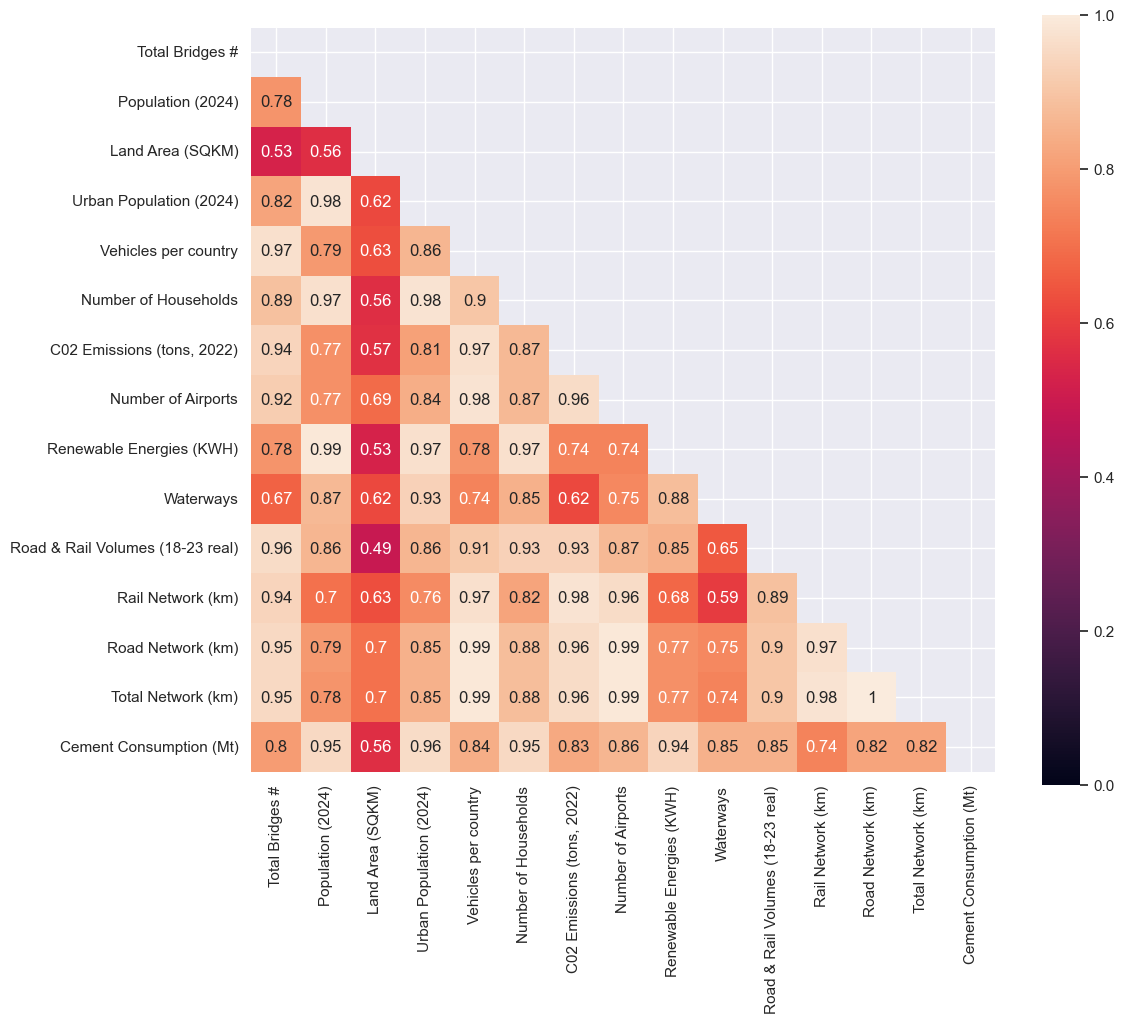

In [31]:
# 1. Correlation Matrix (Pearson)
sample_size_num = sample_size.select_dtypes(include='number')
Pearson_sample = sample_size_num.corr(method="pearson").round(2)
sample_size_mask = np.triu(np.ones_like(Pearson_sample, dtype=bool))
plt.figure(figsize=(12,10)) # width, height
sns.heatmap(Pearson_sample, vmin=0, vmax=1, annot=True, square = True, mask = sample_size_mask);

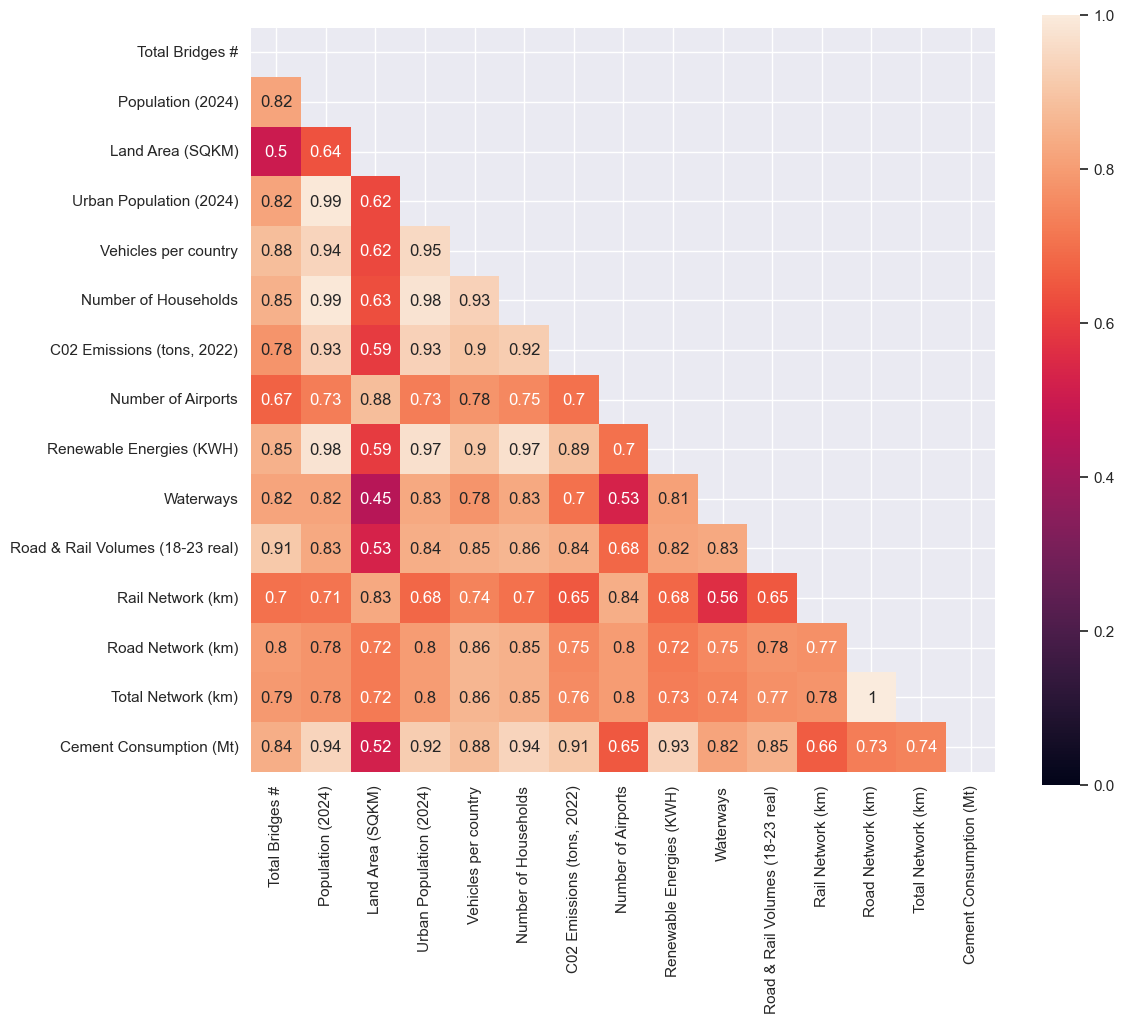

In [32]:
# 2. Correlation Matrix (Spearman)
Spearman_sample = sample_size_num.corr(method="spearman").round(2)
Spearman_sample_mask = np.triu(np.ones_like(Spearman_sample, dtype=bool))
plt.figure(figsize=(12,10)) # width, height
sns.heatmap(Spearman_sample, vmin=0, vmax=1, annot=True, square = True, mask = Spearman_sample_mask);

#### **3. Regression Analysis (Linear & Multivariate)**

#### 3.1 LR: Number of Households

In [33]:
households = sample_size[['Country','Number of Households', 'Total Bridges #']]
# Drop any column with an NaN
households = households.dropna(how='any')
households['Ratio'] = households['Number of Households'] / households['Total Bridges #']
households = households.reset_index(drop=True)

outliers_house=detect_outliers(list(households['Ratio']))
print("The outliers are: " + str(outliers_house))
households

The outliers are: []


,Country,Number of Households,Total Bridges #,Ratio
0,United States,132736055.0,621581.0,213.545869
1,Germany,40624971.0,140000.0,290.178364
2,United Kingdom,29486179.0,107338.0,274.704010
3,France,30217950.0,225000.0,134.302000
4,Brazil,64124398.0,120000.0,534.369983
5,Canada,15618491.0,60021.0,260.217107
6,South Korea,23650555.0,41357.0,571.863409
7,Australia,10220186.0,62840.0,162.638224
8,Indonesia,69855344.0,102300.0,682.847937
9,Netherlands,7874258.0,85000.0,92.638329


In [34]:
y_house = households['Total Bridges #']
x1_house = households['Number of Households']
x_house = sm.add_constant(x1_house)
results_house = sm.OLS(y_house,x_house).fit() # OLS = Ordinary Least Squares Regression
results_house.summary()

c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     61.42
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.82e-07
Time:                        16:14:08   Log-Likelihood:                -237.03
No. Observations:                  19   AIC:                             478.1
Df Residuals:                      17   BIC:                             480.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -788.5197   1.94e+04     -0.041      0.968   -4.18e+04    4.02e+04
Number of Households     0.0037      0.000      7.837      0.000       0.003       0.005
==============================================================================
Omnibus:                        3.644   Durbin-Watson:                   2.551
Prob(Omnibus):                  0.162   Jarque-Bera (JB):                1.640
Skew:                          -0.458   Prob(JB):                        0.441
Kurtosis:                       4.111   Cond. No.                     5.15e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.15e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 3.2 LR: Vehicles per country

In [35]:
vehicles = sample_size[['Country','Vehicles per country', 'Total Bridges #']]

vehicles['Ratio'] = (vehicles['Vehicles per country'] / vehicles['Total Bridges #']).round(2)
# Drop any column with an NaN
vehicles = vehicles.dropna(how='any')
vehicles = vehicles.reset_index(drop=True)
print(vehicles)

outliers_vehicles=detect_outliers(list(vehicles['Ratio']))
print("The outliers are: " + str(outliers_vehicles))

vehicles = vehicles[~vehicles['Country'].isin(['Malaysia'])]
print(vehicles)

           Country  Vehicles per country  Total Bridges #   Ratio
0    United States             305000000         621581.0  490.68
1          Germany              55200000         140000.0  394.29
2   United Kingdom              38000000         107338.0  354.02
3           France              52000000         225000.0  231.11
4           Brazil              88000000         120000.0  733.33
5           Canada              34000000          60021.0  566.47
6      South Korea              26000000          41357.0  628.67
7        Australia              24000000          62840.0  381.92
8        Indonesia              22500000         102300.0  219.94
9      Netherlands              12300000          85000.0  144.71
10     Switzerland               5215771          40000.0  130.39
11          Taiwan               8536705          28000.0  304.88
12         Belgium               8000000          15547.0  514.57
13          Norway               3416216          19731.0  173.14
14        

C:\Users\karavangelis\AppData\Local\Temp\ipykernel_24744\1509769605.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicles['Ratio'] = (vehicles['Vehicles per country'] / vehicles['Total Bridges #']).round(2)


In [36]:
y_vehicles = vehicles['Total Bridges #']
x1_vehicles = vehicles['Vehicles per country']
x_vehicles = sm.add_constant(x1_vehicles)
results_vehicles = sm.OLS(y_vehicles,x_vehicles).fit() # OLS = Ordinary Least Squares Regression
results_vehicles.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     276.0
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           9.00e-13
Time:                        16:14:08   Log-Likelihood:                -248.48
No. Observations:                  21   AIC:                             501.0
Df Residuals:                      19   BIC:                             503.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.688e+04   8687.520      1.943      0.067   -1304.052    3.51e+04
Vehicles per country     0.0020      0.000     16.614      0.000       0.002       0.002
==============================================================================
Omnibus:                       12.622   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.732
Skew:                           1.160   Prob(JB):                      0.00172
Kurtosis:                       6.028   Cond. No.                     8.29e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.29e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

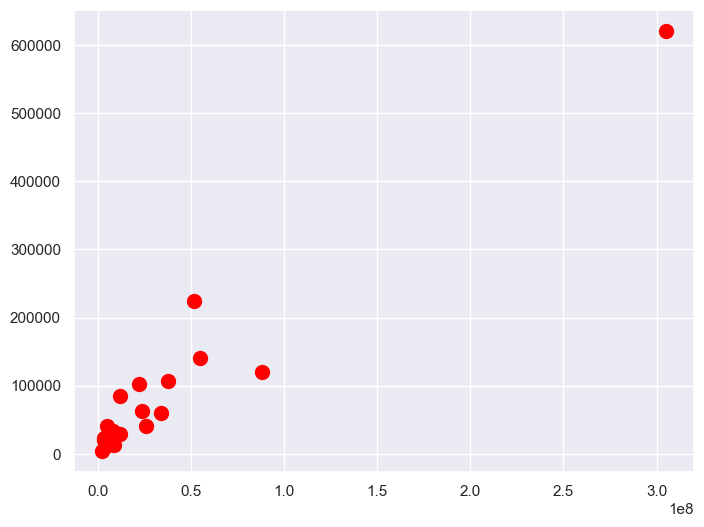

In [37]:
y_vehicles = vehicles['Total Bridges #']
x1_vehicles = vehicles['Vehicles per country']
plt.figure(figsize=(8,6)) # width, height
plt.scatter(x1_vehicles, y_vehicles, s=100, c='red')
#yhat = 1.0865*x1 + 2599.6911
#plt.plot(x1,yhat, lw=4, c='blue', label='regression')
plt.show();

#### 3.3 LR: Road & Rail Volume

In [38]:
volumes = sample_size[['Country','Road & Rail Volumes (18-23 real)', 'Total Bridges #']]
# Setting up of ratio
volumes['Ratio'] = (volumes['Road & Rail Volumes (18-23 real)'] / volumes['Total Bridges #']).round(2)
# Drop any column with an NaN
volumes = volumes.dropna(how='any')
volumes = volumes.reset_index(drop=True)

outliers_volumes=detect_outliers(list(volumes['Ratio']))
print("The outliers are: " + str(outliers_volumes))
volumes

The outliers are: []


C:\Users\karavangelis\AppData\Local\Temp\ipykernel_24744\492159883.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['Ratio'] = (volumes['Road & Rail Volumes (18-23 real)'] / volumes['Total Bridges #']).round(2)


,Country,Road & Rail Volumes (18-23 real),Total Bridges #,Ratio
0,United States,643743.81,621581.0,1.04
1,Germany,164556.01,140000.0,1.18
2,United Kingdom,166646.42,107338.0,1.55
3,France,196679.41,225000.0,0.87
4,Brazil,91602.02,120000.0,0.76
5,Canada,72341.81,60021.0,1.21
6,South Korea,70532.07,41357.0,1.71
7,Australia,87936.03,62840.0,1.40
8,Indonesia,273058.84,102300.0,2.67
9,Netherlands,57646.48,85000.0,0.68


In [39]:
y_volumes = volumes['Total Bridges #']
x1_volumes = volumes['Road & Rail Volumes (18-23 real)']
x_volumes = sm.add_constant(x1_volumes)
results_volumes = sm.OLS(y_volumes,x_volumes).fit() # OLS = Ordinary Least Squares Regression
results_volumes.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     205.1
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.24e-11
Time:                        16:14:09   Log-Likelihood:                -251.37
No. Observations:                  21   AIC:                             506.7
Df Residuals:                      19   BIC:                             508.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                            -6312.1216   1.09e+04     -0.581      0.568   -2.91e+04    1.64e+04
Road & Rail Volumes (18-23 real)     0.9027      0.063     14.320      0.000       0.771       1.035
==============================================================================
Omnibus:                       23.928   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.109
Skew:                          -1.942   Prob(JB):                     1.95e-09
Kurtosis:                       8.545   Cond. No.                     2.14e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.14e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

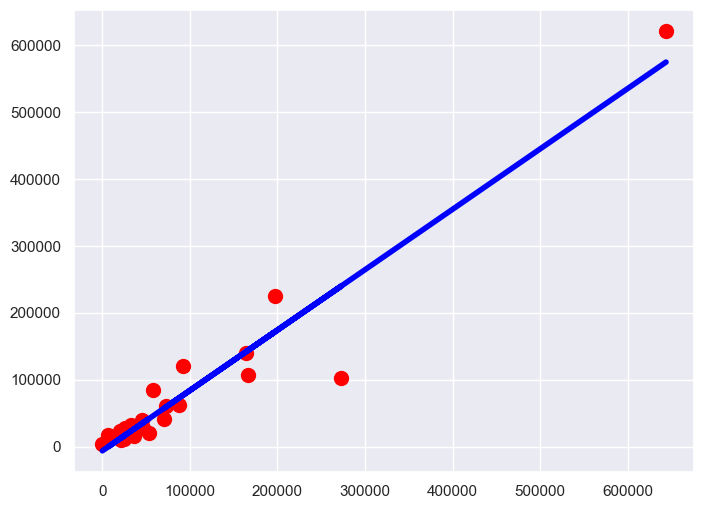

In [40]:
plt.figure(figsize=(8,6)) # width, height
plt.scatter(x1_volumes, y_volumes, s=100, c='red')
yhat = 0.9027*x1_volumes + -6312.1216
plt.plot(x1_volumes ,yhat, lw=4, c='blue', label='regression')
plt.show();

#### 3.4 LR: Total Network Length

In [41]:
Network = sample_size[['Country','Total Network (km)', 'Total Bridges #']]
# Setting up of ratio
Network['Ratio'] = (Network['Total Network (km)'] / Network['Total Bridges #']).round(2)
# Drop any column with an NaN
Network = Network.dropna(how='any')
Network = Network.reset_index(drop=True)
print(Network)

outliers_Network=detect_outliers(list(Network['Ratio']))
print("The outliers are: " + str(outliers_Network))

Network = Network[~Network['Country'].isin(['Saudi Arabia'])]
volumes

           Country  Total Network (km)  Total Bridges #  Ratio
0    United States           6880174.2         621581.0  11.07
1          Germany            870625.0         140000.0   6.22
2   United Kingdom            410818.0         107338.0   3.83
3           France           1082488.0         225000.0   4.81
4           Brazil           2029850.0         120000.0  16.92
5           Canada           1091722.0          60021.0  18.19
6      South Korea            105265.0          41357.0   2.55
7        Australia            909637.0          62840.0  14.48
8        Indonesia            504766.0         102300.0   4.93
9      Netherlands            142179.0          85000.0   1.67
10     Switzerland             76874.0          40000.0   1.92
11          Taiwan             44988.0          28000.0   1.61
12         Belgium            122021.0          15547.0   7.85
13          Norway             99142.0          19731.0   5.02
14         Denmark             77240.0          10000.0

C:\Users\karavangelis\AppData\Local\Temp\ipykernel_24744\868646020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Network['Ratio'] = (Network['Total Network (km)'] / Network['Total Bridges #']).round(2)


,Country,Road & Rail Volumes (18-23 real),Total Bridges #,Ratio
0,United States,643743.81,621581.0,1.04
1,Germany,164556.01,140000.0,1.18
2,United Kingdom,166646.42,107338.0,1.55
3,France,196679.41,225000.0,0.87
4,Brazil,91602.02,120000.0,0.76
5,Canada,72341.81,60021.0,1.21
6,South Korea,70532.07,41357.0,1.71
7,Australia,87936.03,62840.0,1.40
8,Indonesia,273058.84,102300.0,2.67
9,Netherlands,57646.48,85000.0,0.68


In [42]:
y_Network = Network['Total Bridges #']
x1_Network = Network['Total Network (km)']
x_Network = sm.add_constant(x1_Network)
results_Network = sm.OLS(y_Network,x_Network).fit() # OLS = Ordinary Least Squares Regression
results_Network.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     190.3
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.38e-11
Time:                        16:14:09   Log-Likelihood:                -252.09
No. Observations:                  21   AIC:                             508.2
Df Residuals:                      19   BIC:                             510.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2.435e+04   1.01e+04      2.412      0.026    3217.387    4.55e+04
Total Network (km)     0.0853      0.006     13.795      0.000       0.072       0.098
==============================================================================
Omnibus:                        4.326   Durbin-Watson:                   1.675
Prob(Omnibus):                  0.115   Jarque-Bera (JB):                2.278
Skew:                           0.651   Prob(JB):                        0.320
Kurtosis:                       3.954   Cond. No.                     1.82e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

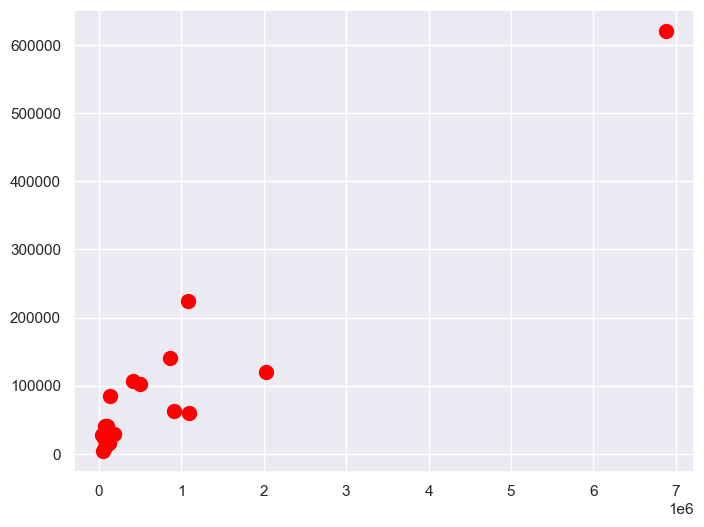

In [43]:
y_Network = Network['Total Bridges #']
x1_Network = Network['Total Network (km)']
plt.figure(figsize=(8,6)) # width, height
plt.scatter(x1_Network, y_Network, s=100, c='red')
#yhat = 1.0865*x1 + 2599.6911
#plt.plot(x1,yhat, lw=4, c='blue', label='regression')
plt.show();

#### 3.5 MVLR: Vehicles + Volumes

In [44]:
MVR1 = sample_size[['Country','Vehicles per country','Road & Rail Volumes (18-23 real)', 'Total Bridges #']]
MVR1 = MVR1[~MVR1['Country'].isin(['Saudi Arabia', 'Malaysia'])]
MVR1 = MVR1.dropna(how='any')
MVR1

,Country,Vehicles per country,Road & Rail Volumes (18-23 real),Total Bridges #
0,United States,305000000,643743.81,621581.0
2,Germany,55200000,164556.01,140000.0
3,United Kingdom,38000000,166646.42,107338.0
4,France,52000000,196679.41,225000.0
5,Brazil,88000000,91602.02,120000.0
6,Canada,34000000,72341.81,60021.0
9,South Korea,26000000,70532.07,41357.0
10,Australia,24000000,87936.03,62840.0
12,Indonesia,22500000,273058.84,102300.0
13,Netherlands,12300000,57646.48,85000.0


In [45]:
y_VV = MVR1['Total Bridges #']
x1_VV = MVR1[['Vehicles per country', 'Road & Rail Volumes (18-23 real)']]
x_VV = sm.add_constant(x1_VV)
results_VV = sm.OLS(y_VV,x_VV).fit() # OLS = Ordinary Least Squares Regression
results_VV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     265.5
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.38e-14
Time:                        16:14:09   Log-Likelihood:                -241.40
No. Observations:                  21   AIC:                             488.8
Df Residuals:                      18   BIC:                             491.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             3200.0933   7165.549      0.447      0.660   -1.19e+04    1.83e+04
Vehicles per country                 0.0012      0.000      5.343      0.000       0.001       0.002
Road & Rail Volumes (18-23 real)     0.4154      0.100      4.166      0.001       0.206       0.625
==============================================================================
Omnibus:                       20.114   Durbin-Watson:                   2.502
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.118
Skew:                           1.785   Prob(JB):                     2.13e-06
Kurtosis:                       7.136   Cond. No.                     9.32e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.32e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 3.6 MVLR: Volume + Total Network

In [46]:
MVR2 = sample_size[['Country','Total Network (km)', 'Road & Rail Volumes (18-23 real)', 'Total Bridges #']]
MVR2 = MVR2[~MVR2['Country'].isin(['Saudi Arabia'])]
MVR2 = MVR2.dropna(how='any')
MVR2

,Country,Total Network (km),Road & Rail Volumes (18-23 real),Total Bridges #
0,United States,6880174.2,643743.81,621581.0
2,Germany,870625.0,164556.01,140000.0
3,United Kingdom,410818.0,166646.42,107338.0
4,France,1082488.0,196679.41,225000.0
5,Brazil,2029850.0,91602.02,120000.0
6,Canada,1091722.0,72341.81,60021.0
9,South Korea,105265.0,70532.07,41357.0
10,Australia,909637.0,87936.03,62840.0
12,Indonesia,504766.0,273058.84,102300.0
13,Netherlands,142179.0,57646.48,85000.0


In [47]:
y_VT = MVR2['Total Bridges #']
x1_VT = MVR2[['Total Network (km)', 'Road & Rail Volumes (18-23 real)']]
#x_VT = sm.add_constant(x1_VT)
results_VT = sm.OLS(y_VT,x1_VT).fit() # OLS = Ordinary Least Squares Regression
results_VT.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:        Total Bridges #   R-squared (uncentered):                   0.972
Model:                            OLS   Adj. R-squared (uncentered):              0.969
Method:                 Least Squares   F-statistic:                              331.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):                    1.67e-15
Time:                        16:14:09   Log-Likelihood:                         -243.39
No. Observations:                  21   AIC:                                      490.8
Df Residuals:                      19   BIC:                                      492.9
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Total Network (km)                   0.0421      0.009      4.727      0.000       0.023       0.061
Road & Rail Volumes (18-23 real)     0.5182      0.084      6.149      0.000       0.342       0.695
==============================================================================
Omnibus:                        7.854   Durbin-Watson:                   2.173
Prob(Omnibus):                  0.020   Jarque-Bera (JB):                6.964
Skew:                           0.639   Prob(JB):                       0.0307
Kurtosis:                       5.515   Cond. No.                         23.2
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **4. Testing**

In [48]:
test = df[['Country','Vehicles per country','Road & Rail Volumes (18-23 real)', 'Total Bridges #','Total Network (km)' ]]
test = test.dropna(how='any')

test['Linear Prediction'] = 0.3643*test['Road & Rail Volumes (18-23 real)'] + 0.0530*test['Total Network (km)']  + 4788.1835
test['Linear Prediction'] = test['Linear Prediction'].astype(int)
test['Deviation'] = (test['Linear Prediction'] / test['Total Bridges #']) - 1
test = test.sort_values(by='Deviation')
test['Deviation'] = test['Deviation'].apply(lambda x: "{:.0%}".format(x))
test = test.drop(['Vehicles per country', 'Road & Rail Volumes (18-23 real)', 'Total Network (km)' ], axis=1)
test

,Country,Total Bridges #,Linear Prediction,Deviation
13,Netherlands,8.500000e+04,33324,-61%
4,France,2.250000e+05,133810,-41%
14,Switzerland,4.000000e+04,25245,-37%
30,Slovakia,2.300000e+04,15430,-33%
23,Romania,3.260500e+04,22404,-31%
2,Germany,1.400000e+05,110879,-21%
28,Greece,1.700000e+04,13585,-20%
3,United Kingdom,1.073380e+05,87270,-19%
15,Taiwan,2.800000e+04,24038,-14%
29,Ukraine,2.845400e+04,24449,-14%


### **5. MVLR: Vehicles, Volume & Network**

In [49]:
MVR3 = sample_size[['Country','Total Network (km)', 'Road & Rail Volumes (18-23 real)', 'Total Bridges #', 'Vehicles per country' ]]
MVR3 = MVR3[~MVR3['Country'].isin(['Saudi Arabia', 'Malaysia'])]
MVR3 = MVR3.dropna(how='any')
MVR3

,Country,Total Network (km),Road & Rail Volumes (18-23 real),Total Bridges #,Vehicles per country
0,United States,6880174.2,643743.81,621581.0,305000000
2,Germany,870625.0,164556.01,140000.0,55200000
3,United Kingdom,410818.0,166646.42,107338.0,38000000
4,France,1082488.0,196679.41,225000.0,52000000
5,Brazil,2029850.0,91602.02,120000.0,88000000
6,Canada,1091722.0,72341.81,60021.0,34000000
9,South Korea,105265.0,70532.07,41357.0,26000000
10,Australia,909637.0,87936.03,62840.0,24000000
12,Indonesia,504766.0,273058.84,102300.0,22500000
13,Netherlands,142179.0,57646.48,85000.0,12300000


In [50]:
y_VVT = MVR3['Total Bridges #']
x1_VVT = MVR3[['Total Network (km)', 'Road & Rail Volumes (18-23 real)','Vehicles per country' ]]
x_VVT = sm.add_constant(x1_VVT)
results_VVT = sm.OLS(y_VVT,x_VVT).fit() # OLS = Ordinary Least Squares Regression
results_VVT.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Total Bridges #   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     167.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           7.92e-13
Time:                        16:14:09   Log-Likelihood:                -241.35
No. Observations:                  21   AIC:                             490.7
Df Residuals:                      17   BIC:                             494.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             2801.8120   7518.045      0.373      0.714   -1.31e+04    1.87e+04
Total Network (km)                  -0.0077      0.030     -0.259      0.799      -0.070       0.055
Road & Rail Volumes (18-23 real)     0.4113      0.104      3.971      0.001       0.193       0.630
Vehicles per country                 0.0013      0.001      1.812      0.088      -0.000       0.003
==============================================================================
Omnibus:                       20.218   Durbin-Watson:                   2.575
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.331
Skew:                           1.794   Prob(JB):                     1.92e-06
Kurtosis:                       7.149   Cond. No.                     9.53e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.53e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""